In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [2]:
df.head()

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [3]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [4]:
mexico =  df[(df["entity"] == "Mexico")]
japon =  df[(df["entity"] == "Japan")]

In [5]:
type(mexico)

pandas.DataFrame

In [6]:
type(mexico["year"])

pandas.Series

In [7]:
anios_mx = mexico["year"].to_numpy()
tasa_mx = mexico["fertility_rate_hist"].to_numpy()

In [8]:
anios_jp = japon["year"].to_numpy()
tasa_jp = japon["fertility_rate_hist"].to_numpy()

In [9]:
promedio_mx = np.mean(tasa_mx)
maximo_mx = np.max(tasa_mx)

promedio_jp = np.mean(tasa_jp)
maximo_jp = np.max(tasa_jp)

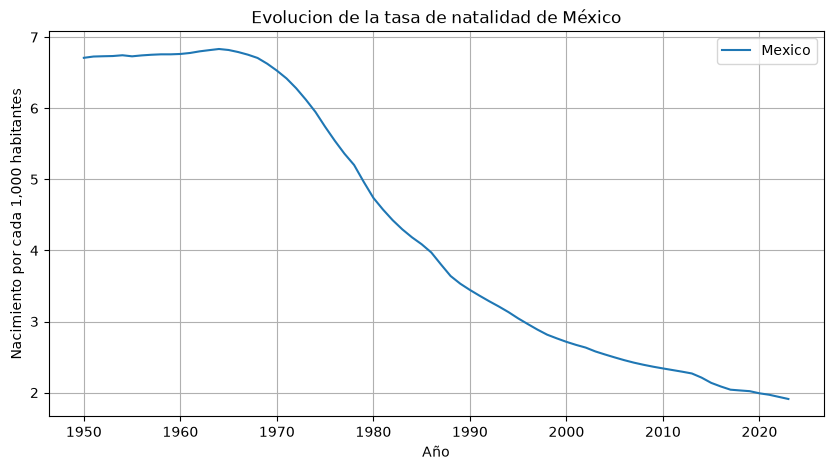

In [10]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mx,
    tasa_mx,
    label ="Mexico"
)

plt.title("Evolucion de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

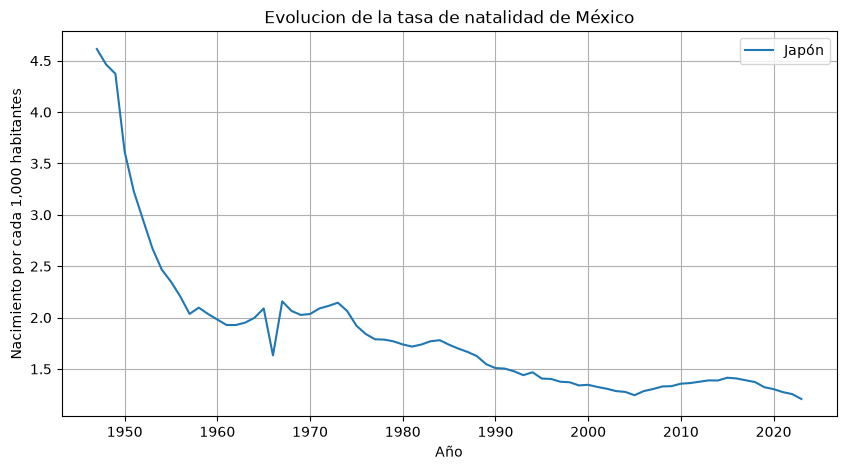

In [11]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_jp,
    tasa_jp,
    label ="Japón"
)

plt.title("Evolucion de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

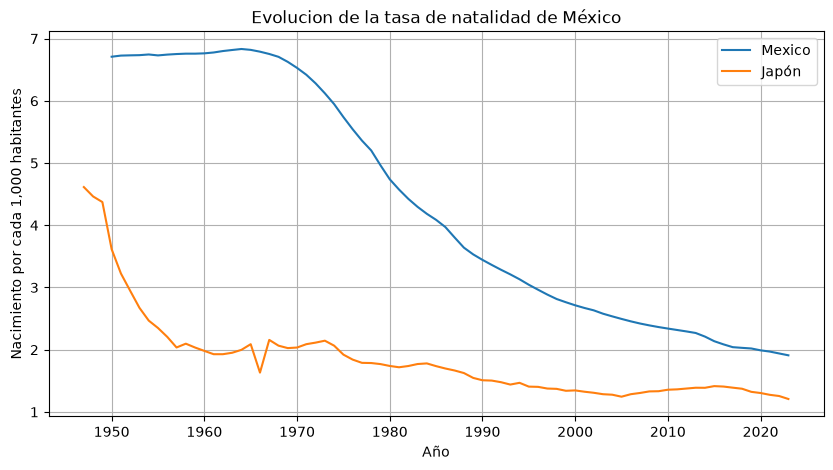

In [12]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mx,
    tasa_mx,
    label ="Mexico"
    
)
plt.plot(
    anios_jp,
    tasa_jp,
    label ="Japón"
)

plt.title("Evolucion de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [13]:
mascara_coincidencia_anios = anios_jp >= anios_mx.min()
mascara_coincidencia_anios


array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [14]:
len(tasa_jp) 

77

In [15]:
anios_jp= np.delete(anios_jp, [30,42,48])

In [16]:
print(anios_jp[30])

1978


In [17]:
anios_comunes= np.intersect1d(
    anios_mx,
    anios_jp
)

In [18]:
len(anios_comunes)

71

In [19]:
mexico_anios_comunes= mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes= japon[japon["year"].isin(anios_comunes)]

In [20]:
mexico_tasa_comuens= mexico_anios_comunes["fertility_rate_hist"].isin(anios_comunes)
japon_tasa_comunes= japon_anios_comunes["fertility_rate_hist"].isin(anios_comunes)

In [21]:
mexico_anios_comunes=mexico_anios_comunes["year"].to_numpy()
japon_anios_comunes=japon_anios_comunes["year"].to_numpy()

mexico_tasa_comuens= mexico_anios_comunes["fertility_rate_hist"].to_numpy()
japon_tasa_comunes= japon_anios_comunes["fertility_rate_hist"].to_numpy()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
comparacion_mex_jap= pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=["_mexico", "_japon"]

)
comparacion_mex_jap.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [ ]:
comparacion_mex_jap["diferencia"] = (
    comparacion_mex_jap["fertility_rate_hist_mexico"]
     - comparacion_mex_jap["fertility_rate_hist_japon"]

)

In [ ]:
comparacion_mex_jap.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon,diferencia
0,1950,6.709,3.615,3.094
1,1951,6.727,3.225,3.502
2,1952,6.731,2.947,3.784


<Figure size 1000x500 with 0 Axes>

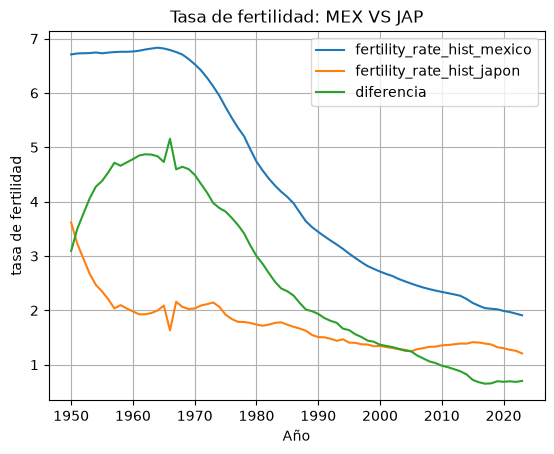

In [ ]:
plt.figure(figsize=(10,5))
comparacion_mex_jap.plot(
    x="year",
    y=["fertility_rate_hist_mexico", "fertility_rate_hist_japon", "diferencia"],
    )
plt.title("Tasa de fertilidad: MEX VS JAP")
plt.xlabel("Año")
plt.ylabel("tasa de fertilidad")
plt.grid(True)
plt.legend()